In [70]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from PIL import Image
import os

In [71]:
current_dir = os.getcwd()

In [72]:
os.listdir(current_dir)

['cat_dogs.ipynb', 'Data']

In [73]:
print("Total cats images " ,len(os.listdir(os.path.join(current_dir, "Data", "images", "cats"))))

Total cats images  348


In [74]:
print("Total dogs images " ,len(os.listdir(os.path.join(current_dir, "Data", "images", "dogs"))))

Total dogs images  348


In [75]:
images_path = os.path.join(current_dir, "Data", "images")

In [76]:
path_dict = {'cats':[], 'dogs':[]}
for dir in os.listdir(images_path):
    dir_path = os.path.join(images_path, dir)
    for images in os.listdir(dir_path):
        path_dict[dir].append(os.path.join(dir_path, images))

In [77]:
# print(path_dict['cats'][:5])
path_dict.values()

dict_values([['c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_1.jpg', 'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_10.jpg', 'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_100.jpg', 'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_101.jpg', 'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_102.jpg', 'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_103.jpg', 'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_104.jpg', 'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog

In [78]:
path_dict

{'cats': ['c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_1.jpg',
  'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_10.jpg',
  'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_100.jpg',
  'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_101.jpg',
  'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_102.jpg',
  'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_103.jpg',
  'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN\\Cat Dog Classification\\Data\\images\\cats\\cat_104.jpg',
  'c:\\Users\\harsh\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CN

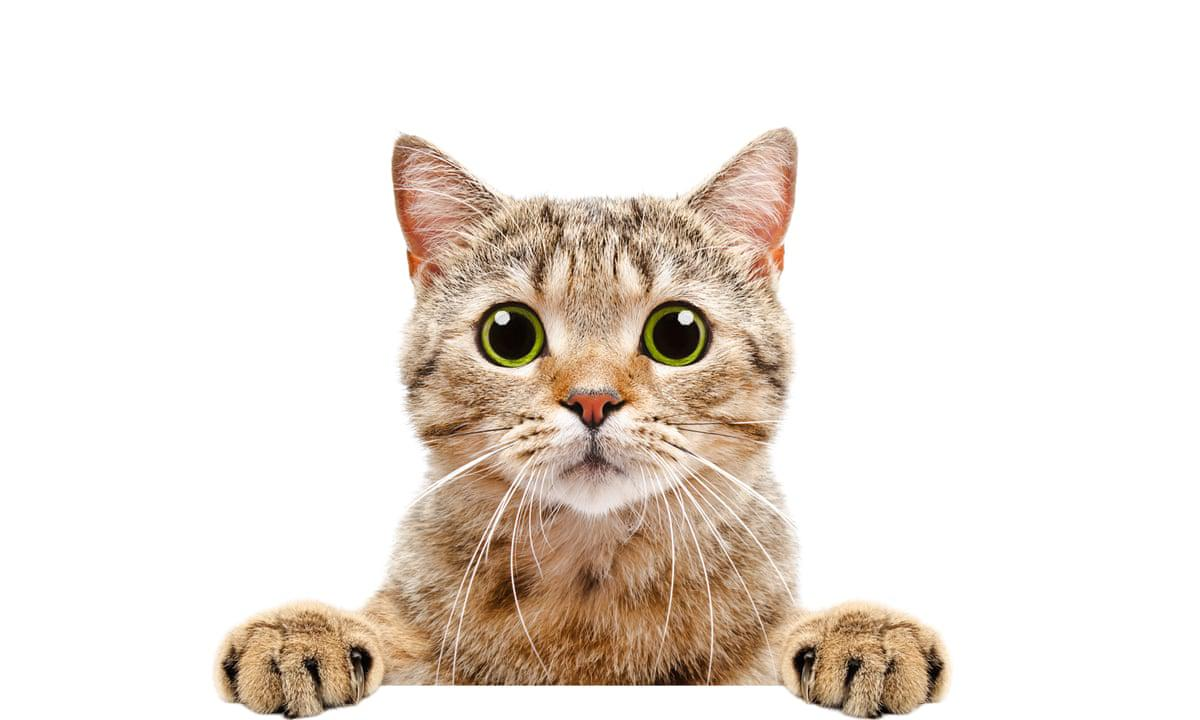

In [79]:
#example to open an image
img = Image.open(path_dict['cats'][7])
img

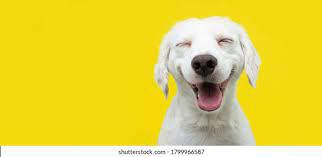

In [80]:
#example to open an image
img = Image.open(path_dict['dogs'][7])
img

In [81]:
import cv2

In [82]:
path_dict.items()

for key, value in path_dict.items():
    print(f"Total {key} images: {len(value)}")

Total cats images: 348
Total dogs images: 348


In [83]:
path_dict.items()
img_arr_lst = [] 
labels = []

for key, value in path_dict.items():
    for path in value:
        imag_arr=cv2.imread(path)
        resizes_img_arr =cv2.resize(imag_arr,(224,224))
        img_arr_lst.append(resizes_img_arr)
        labels.append(key)

In [84]:
print(labels)

['cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',

In [85]:
img_arr_lst = np.array(img_arr_lst)
labels = np.array(labels)
labels

array(['cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
      

In [86]:
labels=np.array([1 if item=='cats' else 0 for item in labels])

In [87]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [88]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(img_arr_lst,labels , test_size=0.2,random_state=42)
x_train.shape , x_test.shape , y_train.shape , y_test.shape
x_train=x_train/255
x_test=x_test/255

In [95]:
model =Sequential([
    Conv2D(62, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [96]:
model.fit(x_train,y_train,epochs=10,batch_size=32,)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.4946 - loss: 0.7112
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5450 - loss: 0.6929
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5342 - loss: 0.6871
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5522 - loss: 0.6810
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6187 - loss: 0.6494
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6978 - loss: 0.5916
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7734 - loss: 0.5131
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7986 - loss: 0.4182
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8579 - loss: 0.3089
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9083 - loss: 0.2307
